# Heat Equation

## Generate Data & Fit Basis

#### Imports & Config

In [1]:
# Start Cell
# Adjust import path
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML
import random

import os
import numpy as np
import matplotlib.pyplot as plt
import opinf
import config
import utils
import step1_generate_data as step1

Logging to log.log


In [2]:
training_span = (0, 1)
num_samples = 65
noiselevel = .01
num_regression_points = 150
numPODmodes = 5
ndraws = 600
time_domain_eval_training = np.linspace(0, training_span[-1], num_regression_points)
normalization = 1e-4
num_initial_conditions = len(config.input_parameters)

### Generate & Visualize Data

In [3]:
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=normalization,
    ndraws=ndraws,
)

sampler = step1.TrajectorySampler(
    training_span,
    num_samples,
    noiselevel,
    num_regression_points,
    synced=False,
)
(
    true_states,
    time_domain_sampled,
    snapshots_sampled,
    training_inputs,
) = sampler.multisample(config.input_parameters, plot=False)

(
    true_states_new_initial,
    time_domain_sampled_new_initial,
    snapshots_sampled_new_initial,
    training_inputs_new_initial,
) = sampler.sample(config.test_parameters)

time_domain = config.time_domain

true_states, time_domain_sampled, snapshots_sampled, training_inputs = np.array(true_states), np.array(time_domain_sampled), np.array(snapshots_sampled), np.array(training_inputs)
true_states.shape, time_domain_sampled.shape, snapshots_sampled.shape, training_inputs.shape, time_domain_eval_training.shape, time_domain.shape, snapshots_sampled_new_initial.shape, training_inputs_new_initial.shape



EXPERIMENTAL SCENARIO
Data:
	* 5 trajectories
	* 65 randomly sampled snapshots in each trajectory
	* 1.00% noise
	* training   0.00 ≤ t < 1.00
	* prediction 0.00 ≤ t ≤ 2.00
Dimension: retaining 5 POD modes
Training: using 150 regression points
GP regularization: eta = 1.00e-04
Posterior: 600 draws



((5, 500, 500),
 (5, 65),
 (5, 500, 65),
 (5, 2, 150),
 (150,),
 (500,),
 (500, 65),
 (2, 150))

#### Quick description of the outputs
for the true states we have (conditions, x, time)
for the training time domian (conditions, training time)

### Fit Basis

reducing noisy training states to 5 dimensions...done in 0.20 s.
(5, 5, 65) (5, 65) (5, 65) (65,)


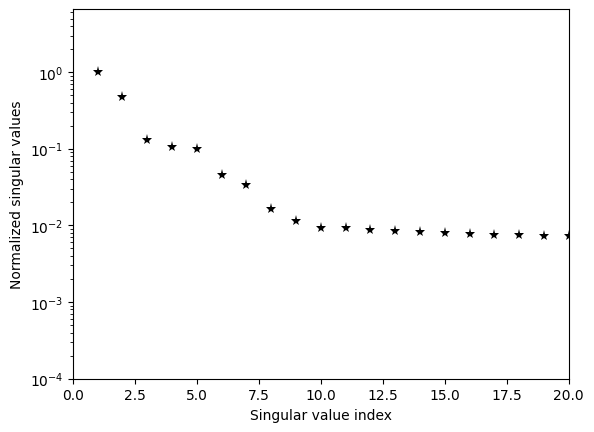

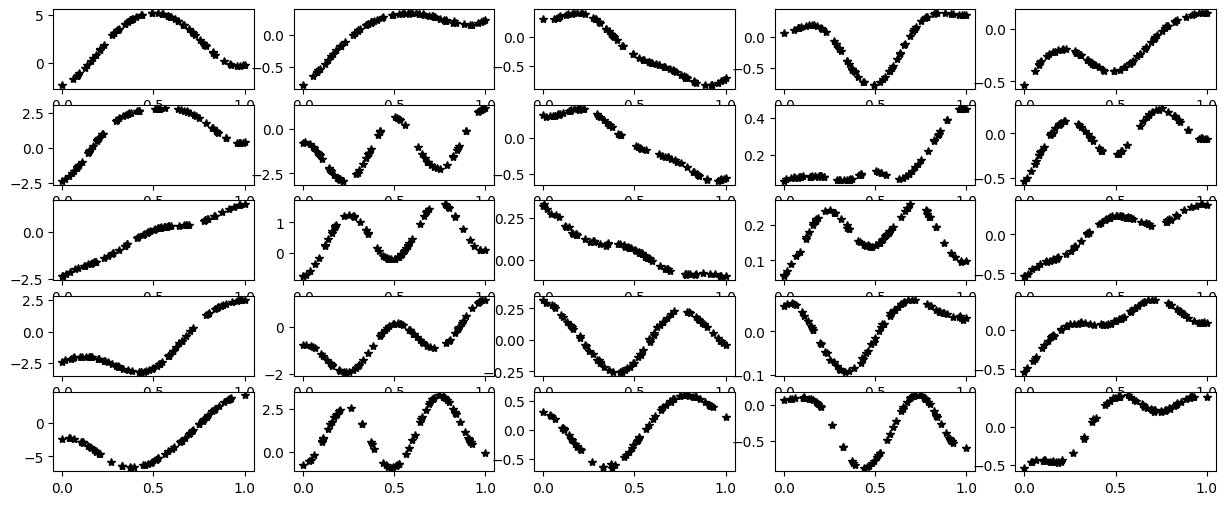

In [4]:
# Start Cell
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    basis.fit(np.hstack(snapshots_sampled))
    ax = basis.plot_svdval_decay()
    ax.set_xlim(right=20)
    ax.set_ylim(bottom=1e-4)
    # utils.save_figure("svdvals.pdf", andopen=openonsave)
    snapshots_compressed = [basis.compress(Q) for Q in snapshots_sampled]
    full_states_compressed = [basis.compress(Q) for Q in true_states]
    snapshots_compressed_new_initial = basis.compress(snapshots_sampled_new_initial)
    full_states_compressed_new_initial = basis.compress(true_states_new_initial)

snapshots_compressed = np.array(snapshots_compressed)
full_states_compressed = np.array(full_states_compressed)
snapshots_compressed_new_initial = np.array(snapshots_compressed_new_initial)
full_states_compressed_new_initial = np.array(full_states_compressed_new_initial)
print(snapshots_compressed.shape, time_domain_sampled.shape, snapshots_compressed_new_initial.shape, time_domain_sampled_new_initial.shape)

fig, ax = plt.subplots(num_initial_conditions, numPODmodes, figsize=(15, 6))
for i in range(num_initial_conditions):
    for j in range(numPODmodes):
        ax[i,j].plot(time_domain_sampled[i], snapshots_compressed[i,j], 'k*', label='True')

## Run Model & Visualize Results

### Bayesian GP

#### Define and Run Model

In [5]:
# Start Cell
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel

kernel = RBFKernel()

def model(
        time: jnp.array, 
        qhat: jnp.array,
        normalization=1e-8,  # Very small regularization
    ):
    num_time_steps = time.shape[1]

    time_range = time.max() - time.min()
    
    
    Ls = []
    Vars = []
    noises = []
    
    for i in range(num_initial_conditions):
        # Analyze data scale
        data_std = jnp.std(qhat[i])
        # Get time scale
        time_range = time[i].max() - time[i].min()
        place_holder_ls = []
        place_holder_vars = []
        place_holder_noises = []
        for j in range(numPODmodes): 
            lengthscale = numpyro.sample(f"lengthscale{i}{j}", 
                                        dist.LogNormal(jnp.log(time_range/1e1), 1.0))
            place_holder_ls.append(lengthscale)
            
            # Variance based on data variance
            variance = numpyro.sample(f"variance{i}{j}", 
                                    dist.LogNormal(jnp.log(data_std**2), 0.5))
            place_holder_vars.append(variance)
            
            # Small noise since data looks clean
            noise = numpyro.sample(f"noise{i}{j}", 
                                dist.LogNormal(-8.0, 1.0))  # Very small noise
            place_holder_noises.append(noise)
            
            # Compute kernel matrix
            K = kernel(time[i].reshape(-1,1), time[i].reshape(-1,1), lengthscale, variance)
            
            # Add tiny regularization for numerical stability
            K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
            
            # GP prior
            x = numpyro.sample(f"f{i}{j}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
            
            # Likelihood
            with numpyro.plate(f"data{i}{j}", num_time_steps):
                numpyro.sample(f"y{i}{j}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i][j])

        Ls.append(place_holder_ls)
        Vars.append(place_holder_vars)
        noises.append(place_holder_noises)

/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:2025-09-29 19:08:49,089:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Starting SVI optimization...
Iteration 0: loss = 13447.2725
Iteration 100: loss = 5943.7168
Iteration 200: loss = 3289.4536
Iteration 300: loss = 2349.9424
Iteration 400: loss = 1913.2992
Iteration 500: loss = 1517.8461
Iteration 600: loss = 1064.7380
Iteration 700: loss = 713.7007
Iteration 800: loss = 357.3990
Iteration 900: loss = 99.4278
Iteration 1000: loss = -247.8327
Iteration 1100: loss = -506.3031
Iteration 1200: loss = -689.9976
Iteration 1300: loss = -962.1592
Iteration 1400: loss = -1230.3384
Iteration 1500: loss = -1407.0480
Iteration 1600: loss = -1530.9518
Iteration 1700: loss = -1721.6547
Iteration 1800: loss = -1898.8812
Iteration 1900: loss = -1987.8976
Iteration 2000: loss = -2130.2639
Iteration 2100: loss = -2255.6050
Iteration 2200: loss = -2366.2869
Iteration 2300: loss = -2372.1689
Iteration 2400: loss = -2545.3372
Iteration 2500: loss = -2653.1689
Iteration 2600: loss = -2674.8137
Iteration 2700: loss = -2728.4846
Iteration 2800: loss = -2809.5381
Iteration 2900

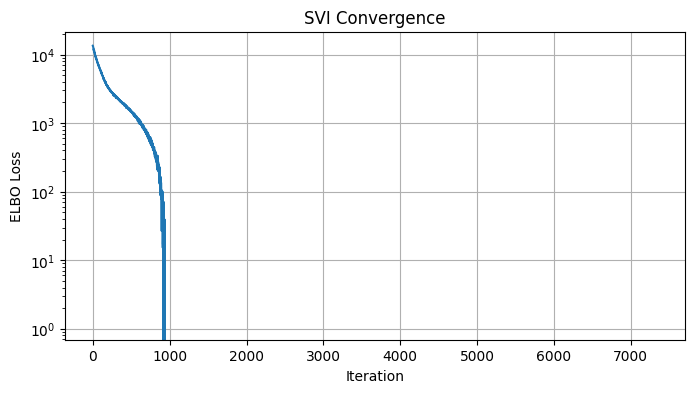

In [6]:
# Create autoguide
guide = autoguide.AutoNormal(model)

# Setup optimizer - start with higher learning rate and decay
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled, 
                                  qhat=snapshots_compressed,
                                  normalization=normalization
                                  )
    return svi_state, loss

# Training loop with patience
num_iterations = 20000  # More iterations
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Rest of your code remains the same...
# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=100)
gp_samples = predictive(rng_key,
                     time=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

#### Visualize

#### A quick descriptions of samples samples[i][j] where i is the po

5


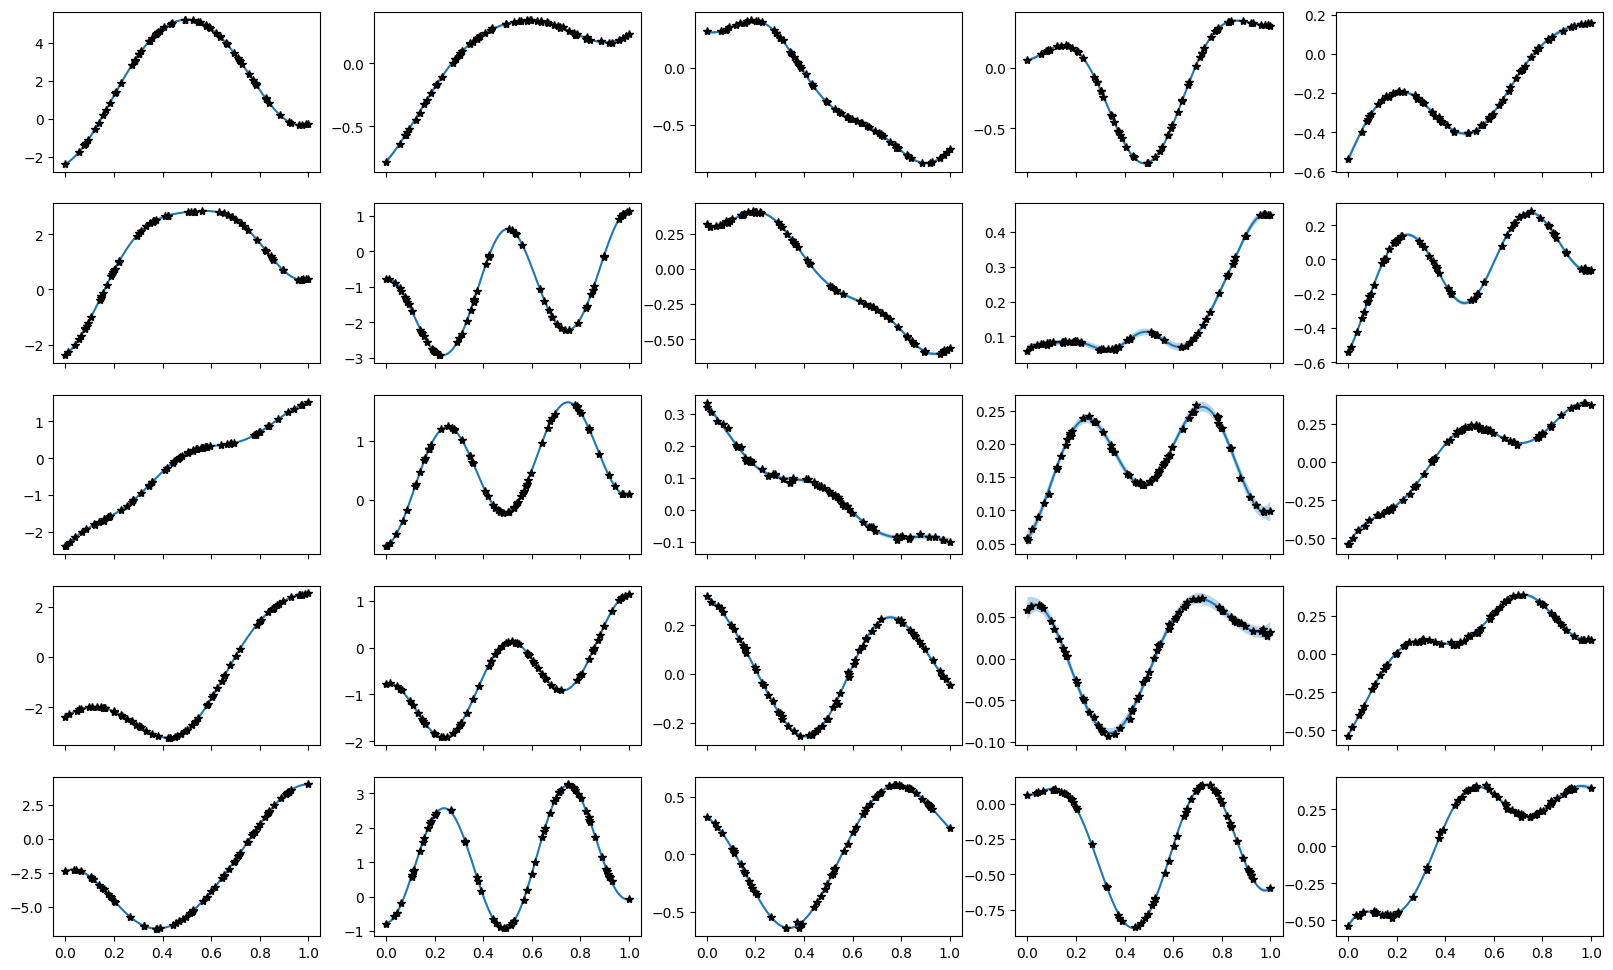

In [7]:
# Plot posterior samples
import heat_plotter
import importlib
importlib.reload(heat_plotter)

plotter = heat_plotter.HeatPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_prediction=time_domain,
            time_domain_eval_prediction=time_domain, # Use full time domain for eval as used in the full order states
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )
plotter.gp_plot_state(
    samples = gp_samples,
)

In [8]:
# Start Cell
### Compute mean and std of each thing that we need

Ls_means, Ls_stds, Ls_covs, Vs_means, Vs_stds, Vs_covs, Ns_means, Ns_stds, Ns_covs, Fs_means = [],[],[],[],[],[],[],[],[],[]
for i in range(numPODmodes):
    Ls_means.append(np.array([gp_samples[f'lengthscale{i}{j}'].mean() for j in range(num_initial_conditions)]))
    Ls_stds.append(np.array([gp_samples[f'lengthscale{i}{j}'].std() for j in range(num_initial_conditions)]))
    Ls_covs.append(np.array([jnp.cov(gp_samples[f'lengthscale{i}{j}']) for j in range(num_initial_conditions)]))
    
    Vs_means.append(np.array([gp_samples[f'variance{i}{j}'].mean() for j in range(num_initial_conditions)]))
    Vs_stds.append(np.array([gp_samples[f'variance{i}{j}'].std() for j in range(num_initial_conditions)]))
    Vs_covs.append(np.array([jnp.cov(gp_samples[f'variance{i}{j}']) for j in range(num_initial_conditions)]))
    
    Ns_means.append(np.array([gp_samples[f'noise{i}{j}'].mean() for j in range(num_initial_conditions)]))
    Ns_stds.append(np.array([gp_samples[f'noise{i}{j}'].std() for j in range(num_initial_conditions)]))
    Ns_covs.append(np.array([jnp.cov(gp_samples[f'noise{i}{j}']) for j in range(num_initial_conditions)]))
    
    Fs_means.append(np.array([gp_samples[f'f{i}{j}'].mean(axis=0) for j in range(num_initial_conditions)]))

Ls_means = np.stack(Ls_means)   # → (numPODmodes, n_snapshots)
Ls_stds  = np.stack(Ls_stds)
Ls_covs = np.stack(Ls_covs)
Vs_means = np.stack(Vs_means)
Vs_stds  = np.stack(Vs_stds)
Vs_covs = np.stack(Vs_covs)
Ns_means = np.stack(Ns_means)
Ns_stds  = np.stack(Ns_stds)
Ns_covs = np.stack(Ns_covs)
Fs_means = np.stack(Fs_means) 
Ls_means.shape, Ls_stds.shape, Ls_covs.shape, Vs_means.shape, Vs_stds.shape, Vs_covs.shape, Ns_means.shape, Ns_stds.shape, Ns_covs.shape, Fs_means.shape

((5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5, 65))

(65, 150)


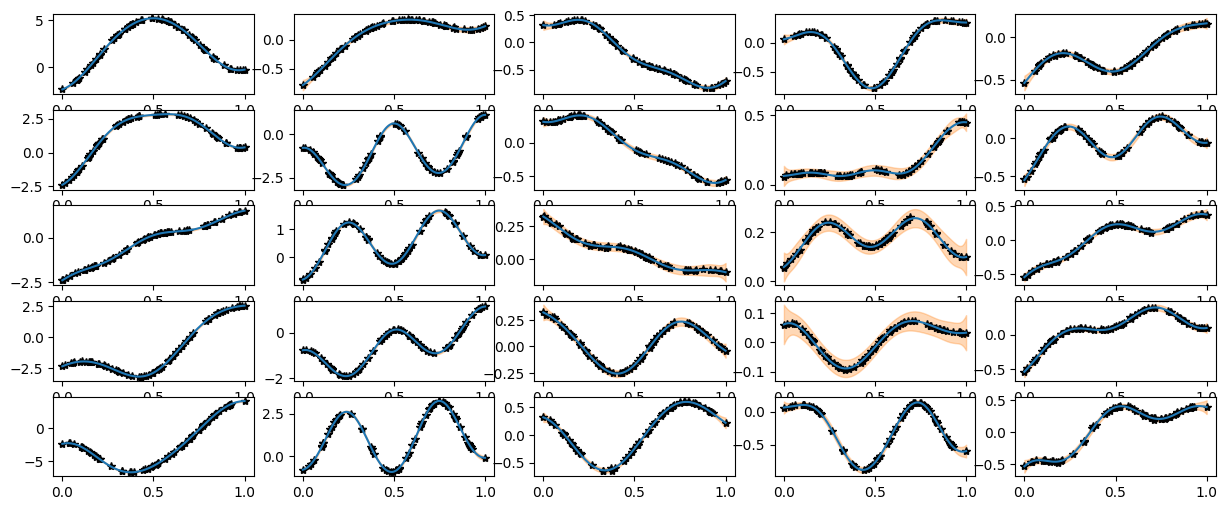

In [9]:
### Plot gp predictions
from helpers.bgp_jax import BayesianGP

eval_points = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)] 
eval_stds = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)] 

gp = BayesianGP()
for i in range(num_initial_conditions):
    for j in range(numPODmodes):
        gp_samples[f'Xi{i}{j}'] = []
        gp_samples[f'XiStd{i}{j}'] = []

        for k in range(num_samples):
            rand_idx = random.randint(0, len(gp_samples['lengthscale00']))
            Ls = gp_samples[f'lengthscale{i}{j}'][rand_idx]
            Vs = gp_samples[f'variance{i}{j}'][rand_idx]
            Ns = gp_samples[f'noise{i}{j}'][rand_idx]

            gp.X_train = time_domain_sampled[i, :][:, None]
            gp.y_train = snapshots_compressed[i, j]
            mean, std, _ = gp.predict_with_hypers(X_test=time_domain_sampled[i, :][:, None], lengthscale=Ls, variance=Vs, noise=Ns)
            mean_test, std_test, _ = gp.predict_with_hypers(X_test=time_domain_eval_training[:, None], lengthscale=Ls, variance=Vs, noise=Ns)
            gp_samples[f'Xi{i}{j}'].append(mean_test)
            gp_samples[f'XiStd{i}{j}'].append(std_test)
        
        gp_samples[f'Xi{i}{j}'] = np.array(gp_samples[f'Xi{i}{j}'])  # Shape (num_samples, num_regression_points)
        gp_samples[f'XiStd{i}{j}'] = np.array(gp_samples[f'XiStd{i}{j}'])  # Shape (num_samples, num_regression_points)
        eval_points[i][j] = gp_samples[f'Xi{i}{j}'].mean(axis=0)
        eval_stds[i][j] = gp_samples[f'XiStd{i}{j}'].mean(axis=0)


print(gp_samples[f'Xi{0}{0}'].shape)

fig, ax = plt.subplots(num_initial_conditions, numPODmodes, figsize=(15, 6))

for i in range(num_initial_conditions):
    for j in range(numPODmodes):
        ax[i,j].plot(time_domain_sampled[i], snapshots_compressed[i,j], 'k*', label='True')
        ax[i,j].plot(time_domain_eval_training, eval_points[i][j], label='Mean prediction')
        ax[i,j].fill_between(time_domain_eval_training, 
                            eval_points[i][j]-10*eval_stds[i][j], 
                            eval_points[i][j]+10*eval_stds[i][j], 
                            color='tab:orange', alpha=0.3, label='Uncertainty (2 std)')

In [10]:
### Dummy rom solve
kernel = RBFKernel()
rom = config.ReducedOrderModel()

ddt = opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled[0])
_states, ddts, _ = ddt.estimate(states=snapshots_compressed[0,:,:], inputs=training_inputs[0,:, :snapshots_compressed[0,:,:].shape[-1]])
rom.fit(snapshots_compressed[0,:,:], ddts = ddts, inputs=training_inputs[0,:, :snapshots_compressed[0,:,:].shape[-1]])

loaded_operator = rom.operator_matrix

In [11]:
def flatten_time(t: jnp.ndarray) -> jnp.ndarray:
    """Return t with shape (n,) no matter if (n,), (n,1) or (1,n) was given."""
    return jnp.ravel(t)

def rbf_eval(lengthscale: float, variance: float, t: jnp.ndarray, t2: jnp.ndarray) -> jnp.ndarray:
    """Full n×n RBF kernel matrix K_ij = variance * exp(-(t_i-t_j)^2 / (2*ell^2))."""
    t = flatten_time(t)
    t2 = flatten_time(t2)
    diff = t[:, None] - t2[None, :]
    ell2 = lengthscale ** 2
    return variance * jnp.exp(-diff**2 / (2.0 * ell2))

def joint_gp_derivatives(Ls, Vs, time1, time2, snapshots_compressed):
    print(f'Time shapes in joint gp call {time1.shape}, {time2.shape}')
    K_yys = []
    K_zys = []
    K_zzs = []
    for i in range(numPODmodes):
        print(f'joint gp derivates ls shape {jnp.array(Ls).shape}')
        ell2 = Ls[i]**2
        
        # Standard RBF kernels
        rbf_yy = rbf_eval(Ls[i], Vs[i], time1, time1) 
        rbf_zy = rbf_eval(Ls[i], Vs[i], time2, time1)
        rbf_zz = rbf_eval(Ls[i], Vs[i], time2, time2)

        print(f"kernel shapes {rbf_yy.shape}, {rbf_zy.shape}, {rbf_zz.shape}")
        
        # K_yy with noise term
        print(rbf_yy.shape, time1.shape)
        K_yy = rbf_yy + 1e-5 * np.eye(len(time1))  # Fixed: use eye instead of diag
        
        # K_zy: derivative kernel - note the correct difference computation
        diff_zy = time2[:, None] - time1[None, :]  # (250, 150)
        K_zy = -(diff_zy / ell2) * rbf_zy  # (250, 150)
        
        # K_zz: second derivative kernel
        diff_zz = time2[:, None] - time2[None, :]  # (250, 250)
        K_zz = ((1 - (diff_zz**2 / ell2)) / ell2) * rbf_zz  # (250, 250)
        
        K_yys.append(K_yy)
        K_zys.append(K_zy)
        K_zzs.append(K_zz)

    # Now the prediction should work
    mu_z = []
    cov_z = []
    for i in range(numPODmodes):
        w = jnp.linalg.solve(K_yys[i], snapshots_compressed[i])  # w shape: (150,)
        mu_zi = K_zys[i] @ w  # (250, 150) @ (150,) = (250,)
        mu_z.append(mu_zi)

        cov_zi = K_zzs[i] - K_zys[i] @ jnp.linalg.solve(K_yys[i], K_zys[i].T)
        cov_z.append(cov_zi)

    return jnp.array(mu_z), jnp.array(cov_z)  # Shape should be (6, 250)

In [12]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()


def model(time, normalization=1e-6):
    num_time_steps = time.shape[0]
    gamma = 1e1 #4e2, 1e0

    min_std = 2e1   # lower bound
    factor  = 0.5   # scaling factor

    # O = numpyro.sample(
    #     "O",
    #     dist.Normal(
    #         loc=loaded_operator,
    #         scale=jnp.maximum(min_std, factor * jnp.abs(loaded_operator))
    #     )
    # )

    O = numpyro.sample(
        "O",
        dist.Normal(
            loc=jnp.zeros_like(loaded_operator),
            scale=gamma * jnp.ones_like(loaded_operator)
        )
    )

    Xs = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    Ls = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    Vars = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    noises = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    Kyys = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    
    for i in range(num_initial_conditions):
        for j in range(numPODmodes):
            lengthscale = Ls_means[i][j]
            Ls[i][j].append(lengthscale)

            variance = Vs_means[i][j]
            Vars[i][j].append(variance)

            noise = Ns_means[i][j]
            noises[i][j].append(noise)

            Kyy = get_c_phi(lengthscale, variance, time, normalization)
            Kyys[i][j].append(Kyy)

            Xs[i][j].append(
                numpyro.sample(
                    f"X{i}{j}",
                    dist.MultivariateNormal(loc=eval_points[i][j], covariance_matrix=jnp.diag(eval_stds[i][j])+normalization*jnp.eye(eval_stds[i][j].shape[0])),
                )
            )
        
        Ls[i] = jnp.array(Ls[i]).squeeze()
        Vars[i] = jnp.array(Vars[i]).squeeze()
        noises[i] = jnp.array(noises[i]).squeeze()
        Kyys[i] = jnp.array(Kyys[i]).squeeze()
        Xs[i] = jnp.array(Xs[i]).squeeze()
    
    Ls = jnp.array(Ls)
    Vars = jnp.array(Vars)
    noises = jnp.array(noises)
    Kyys = jnp.array(Kyys)
    Xs = jnp.array(Xs)
    print(f"shapes of all the hypers and xs: {Ls.shape}, {Vars.shape}, {noises.shape}, {Kyys.shape}, {Xs.shape}")
        
    for i in range(num_initial_conditions):
        f_Xi_ohat = rom._assemble_data_matrix(Xs[i], inputs=training_inputs[i]) @ O.T

        mu_z, cov_z = joint_gp_derivatives(Ls[i], Vars[i], time_domain_sampled[i], time, snapshots_compressed=snapshots_compressed[i])
    
        for j in range(numPODmodes):
            mu_zi = mu_z[j]
            cov_zi = cov_z[j]
            constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)

            numpyro.sample(
                f'ode_constraint{i}{j}',
                dist.MultivariateNormal(mu_zi, constraint_cov),
                obs=f_Xi_ohat.T[j]
            )

shapes of all the hypers and xs: (5, 5), (5, 5), (5, 5), (5, 5, 150, 150), (5, 5, 150)
Time shapes in joint gp call (65,), (150,)
joint gp derivates ls shape (5,)
kernel shapes (65, 65), (150, 65), (150, 150)
(65, 65) (65,)
joint gp derivates ls shape (5,)
kernel shapes (65, 65), (150, 65), (150, 150)
(65, 65) (65,)
joint gp derivates ls shape (5,)
kernel shapes (65, 65), (150, 65), (150, 150)
(65, 65) (65,)
joint gp derivates ls shape (5,)
kernel shapes (65, 65), (150, 65), (150, 150)
(65, 65) (65,)
joint gp derivates ls shape (5,)
kernel shapes (65, 65), (150, 65), (150, 150)
(65, 65) (65,)
Time shapes in joint gp call (65,), (150,)
joint gp derivates ls shape (5,)
kernel shapes (65, 65), (150, 65), (150, 150)
(65, 65) (65,)
joint gp derivates ls shape (5,)
kernel shapes (65, 65), (150, 65), (150, 150)
(65, 65) (65,)
joint gp derivates ls shape (5,)
kernel shapes (65, 65), (150, 65), (150, 150)
(65, 65) (65,)
joint gp derivates ls shape (5,)
kernel shapes (65, 65), (150, 65), (150, 1

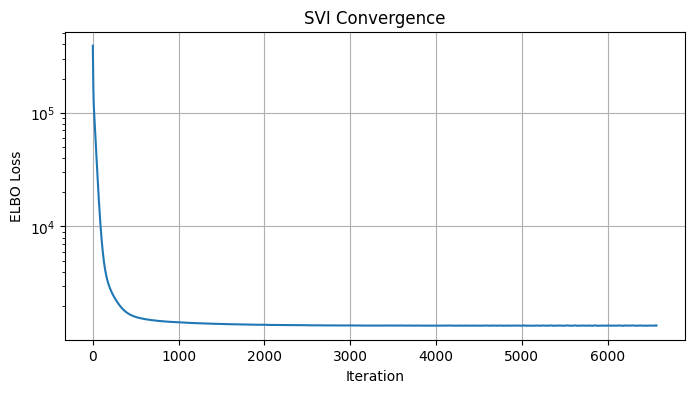

In [13]:
guide = autoguide.AutoDelta(model)

normalization = 1e-6

optimizer = Adam(step_size=0.1)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

svi_state = svi.init(rng_key,
                     time=time_domain_eval_training, 
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_eval_training, 
                                  normalization=normalization
                                  )
    return svi_state, loss

num_iterations = 100000
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (patience_counter > patience and i > 5000):
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
gm_samples = predictive(rng_key,
                     time=time_domain_eval_training, 
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

In [14]:
samples = gm_samples

In [15]:
Os = []
Xs = [[] for i in range(num_initial_conditions)]
rom_solves = [[] for i in range(num_initial_conditions)]

# TODO: Add support for test initial condition
for i in range(num_initial_conditions):
    for j in range(ndraws):
        O = samples['O'][j]
        if i == 0:
            Os.append(O)
        rom._extract_operators(np.array(O))
        Xs[i].append(np.array([samples[f'X{i}{k}'][j] for k in range(numPODmodes)]))
        rom.predict(state0=snapshots_compressed[i, :, 0], t=time_domain_eval_training, input_func=config.input_func_factory(config.input_parameters[i]))

        if rom.predict_result_.y.shape[1] < time_domain_eval_training.size:
            print("Bad solve, skipping", rom.predict_result_.y.shape)
            continue
        rom_solves[i].append(rom.predict_result_.y)

rom_solves_new_initial = []
Os = np.array(Os)

for i in range(ndraws):
    O = samples['O'][i]
    rom._extract_operators(np.array(O))
    rom.predict(state0=snapshots_compressed_new_initial[:, 0], t=time_domain_eval_training, input_func=config.input_func_factory(config.test_parameters))
    if rom.predict_result_.y.shape[1] < time_domain_eval_training.size:
        print("Bad solve, skipping", rom.predict_result_.y.shape)
        continue

    rom_solves_new_initial.append(rom.predict_result_.y)

(100, 5, 150)
(100, 5, 500)
(100, 5, 150)
(100, 5, 500)
(100, 5, 150)
(100, 5, 500)
(100, 5, 150)
(100, 5, 500)
(100, 5, 150)
(100, 5, 500)
(100, 5, 150)
(100, 5, 500)
(100, 6, 5, 150) (100, 6, 5, 500)


<Figure size 640x480 with 0 Axes>

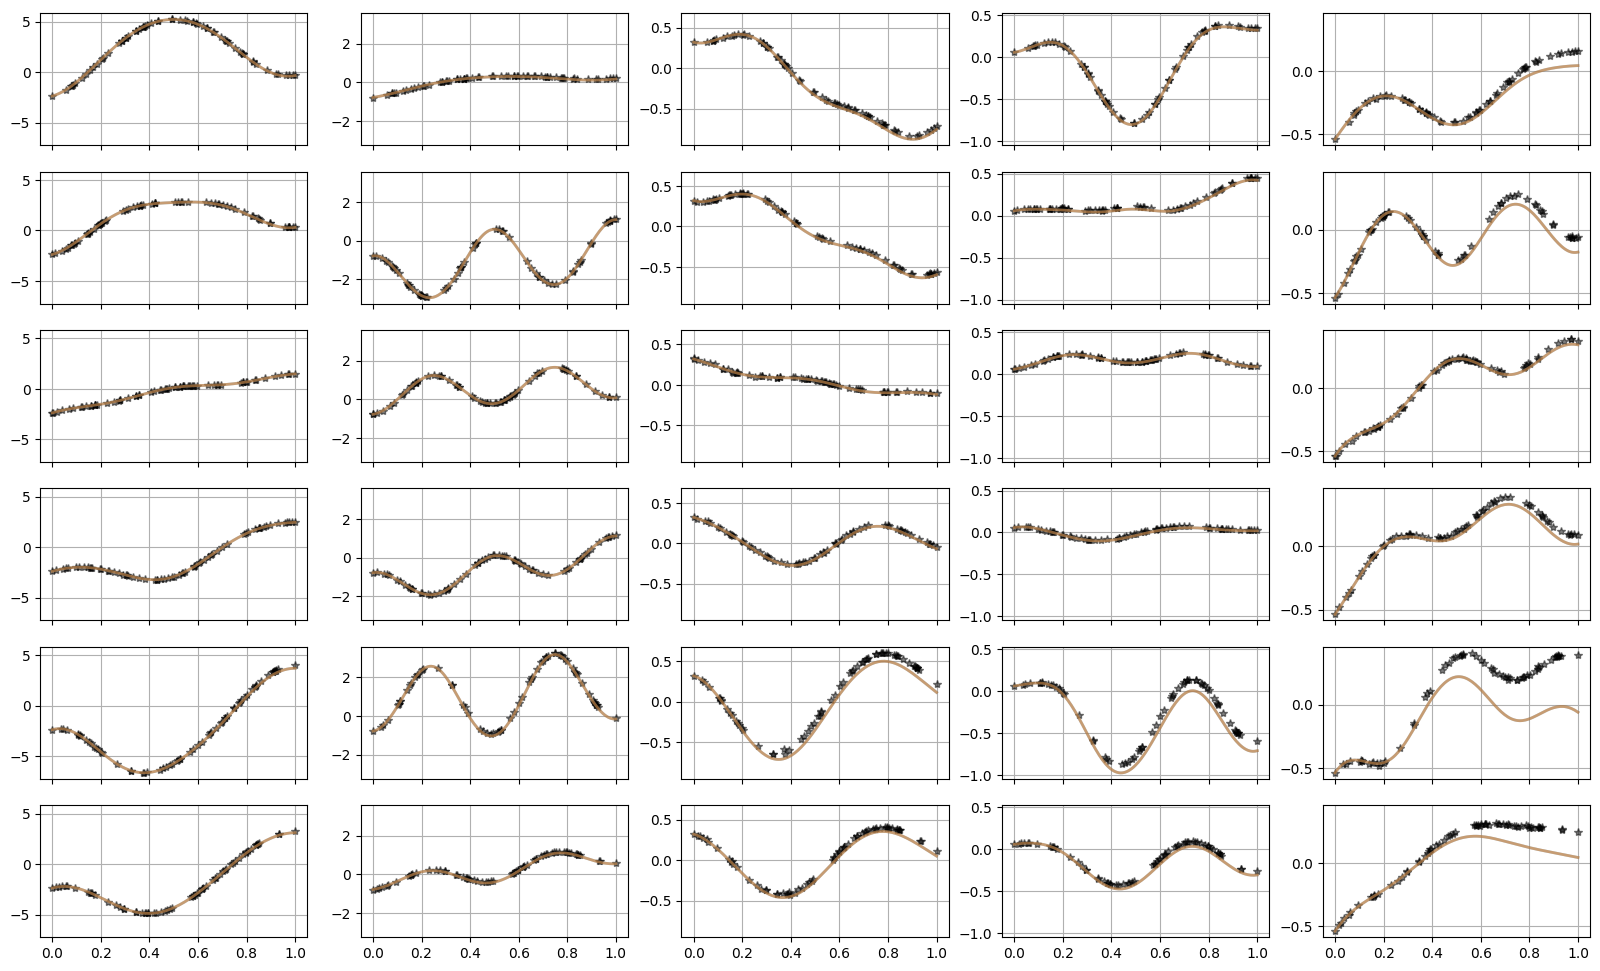

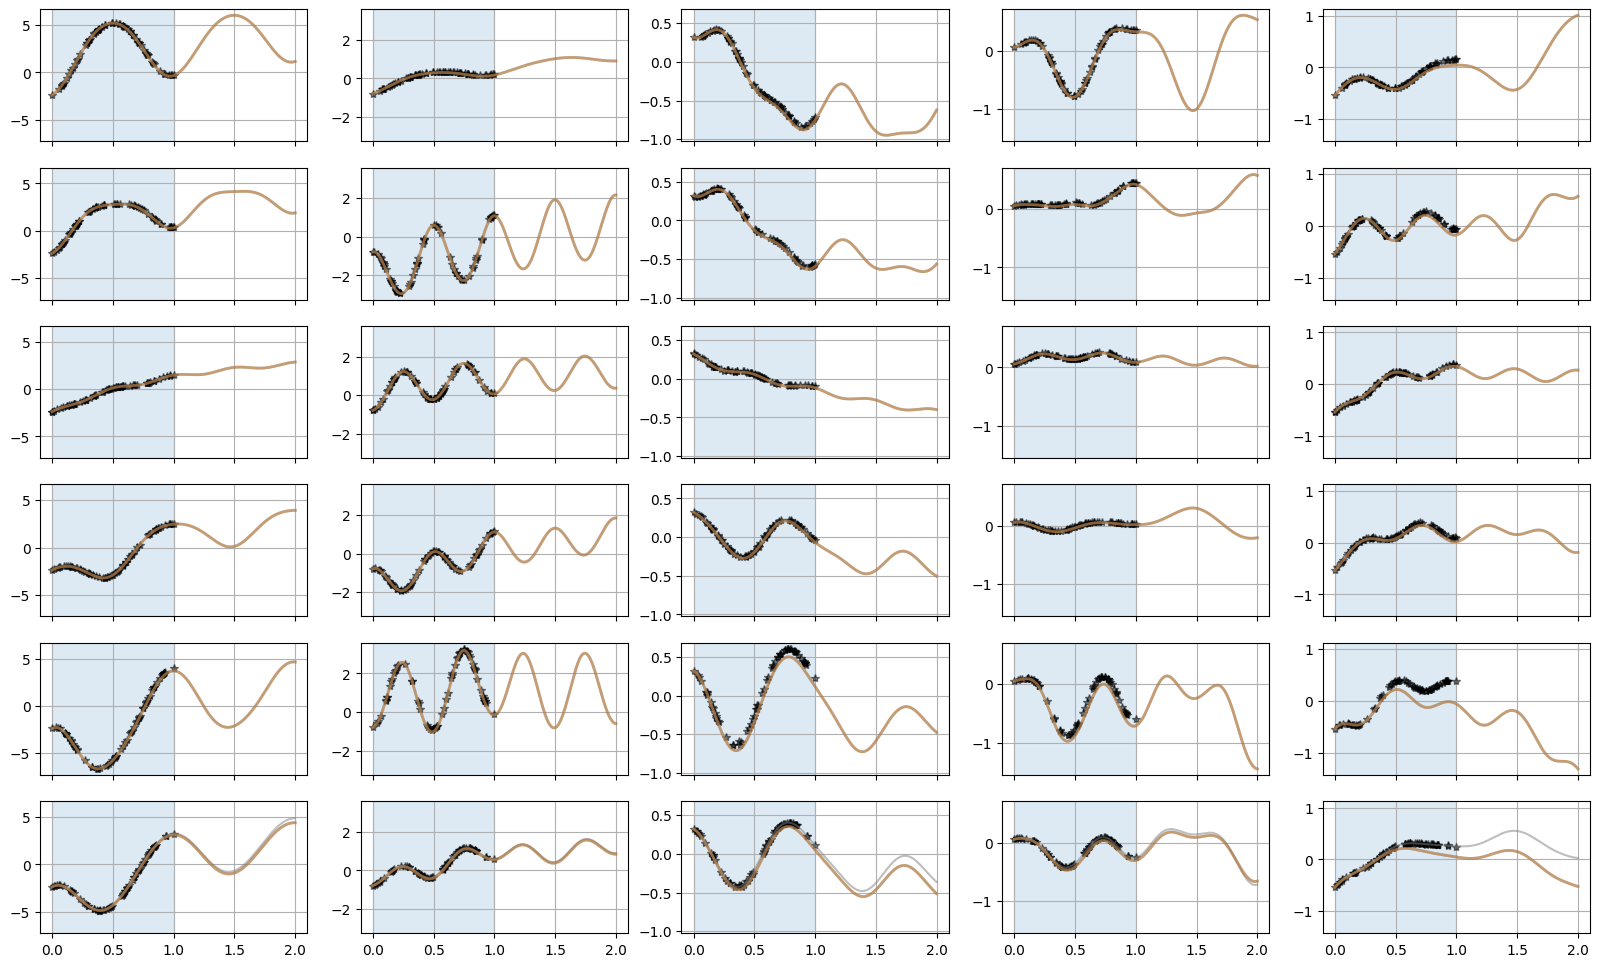

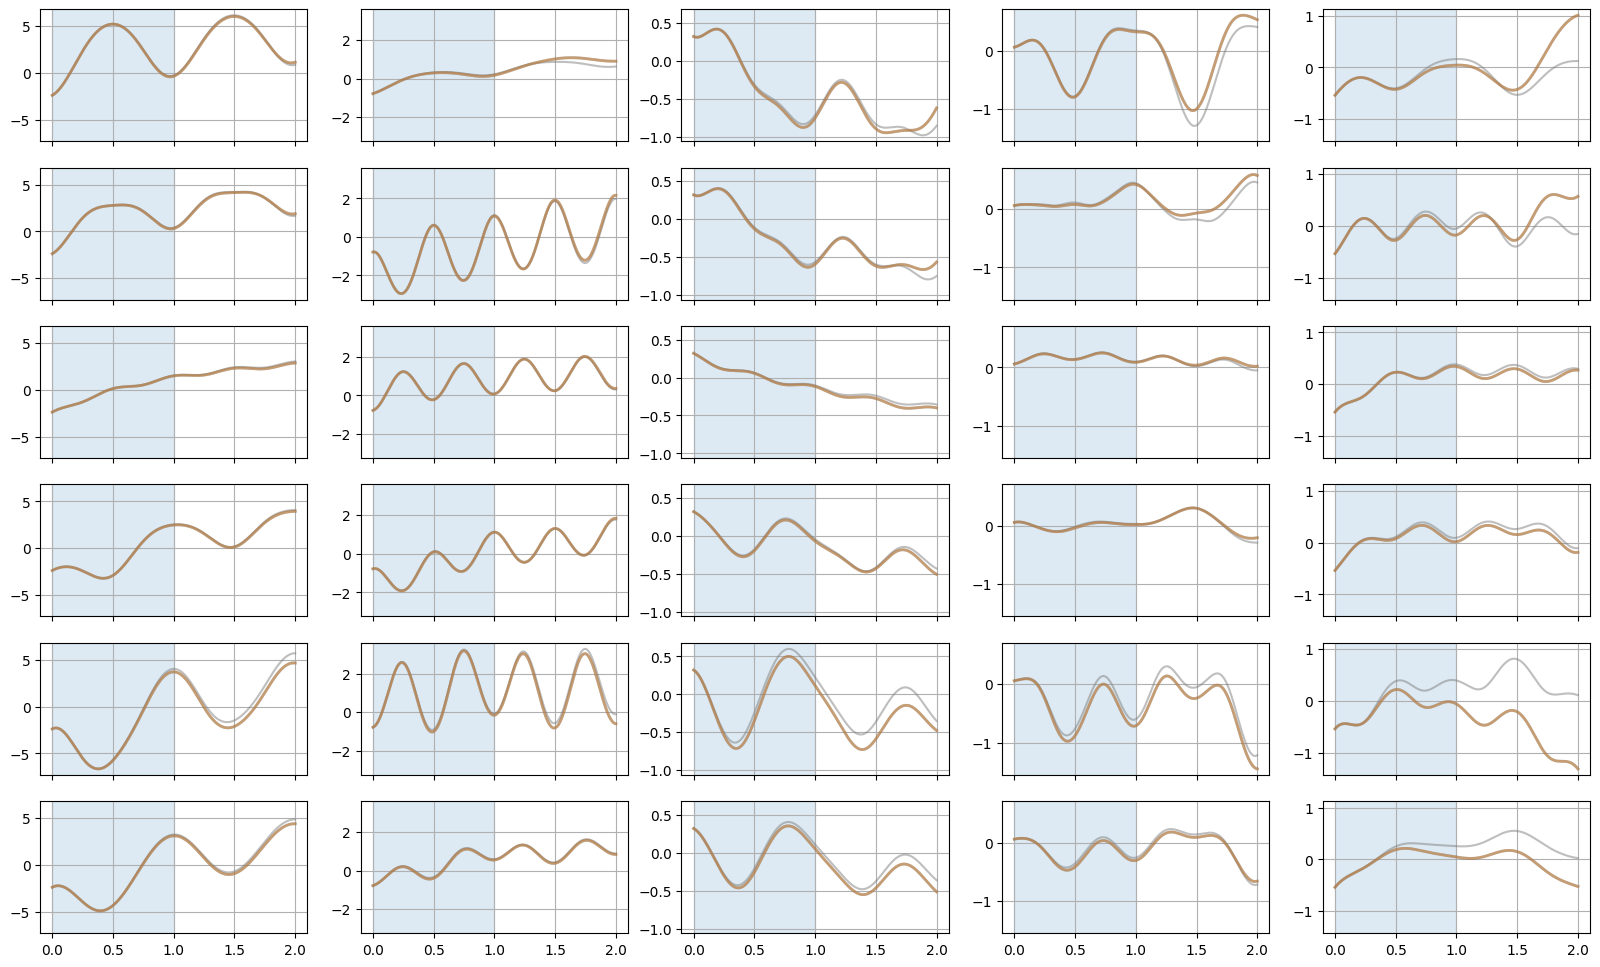

In [18]:
# Plot posterior samples
import heat_plotter
import importlib
importlib.reload(heat_plotter)

plotter = heat_plotter.HeatPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_prediction=time_domain,
            time_domain_eval_prediction=time_domain, # Use full time domain for eval as used in the full order states
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )

plotter.operator_plot(
    # TODO: fix this cheating
    q0 = None,
    operator_samples = Os,
    latent_state_samples = Xs,
    snapshots_training_prediction_parameters = snapshots_compressed_new_initial,
    time_domain_training_prediction_parameters = time_domain_sampled_new_initial,
    snapshots_prediction_new_initial = full_states_compressed_new_initial,
    rom = rom,
    input_func = config.input_func_factory,
    input_parameters_training = config.input_parameters,
    input_parameters_prediction = config.test_parameters,
    figsize = (20, 12),
    max_num_samples = 100,
    plot_samples = False
)